In [16]:
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display
import matplotlib.image as mpimg
import cartopy.crs as ccrs
import xarray as xr
import numpy as np
from scipy.stats import spearmanr, linregress
import config 
import analysis_lib as alib 
from pathlib import Path
from PIL import Image

# --- CONFIGURATION ---
TS_START_YEAR = 1975
TS_END_YEAR = config.TS_END_YEAR  
CORE_START = config.START_YEAR    
CORE_END = config.END_YEAR        

TARGET_DRIVERS = [
    'ENSO', 'IOD', 'WPO', 'WIO', 
    'Niño1+2', 'Nino1+2', 'Niño3', 'Nino3', 
    'Niño4', 'Nino4'
]

In [17]:
def get_valid_drivers(extras_dict):
    for index_name in extras_dict.keys():
        if any(d.lower() in index_name.lower() for d in TARGET_DRIVERS):
            yield index_name

def standardize_series(da, smooth_years=None):
    if da is None: return None
    if smooth_years is not None and len(da) > smooth_years:
        da = da.rolling(time=smooth_years, center=True).mean()
    mean_val = da.mean(dim='time')
    std_val = da.std(dim='time')
    if float(std_val) == 0: return da 
    return (da - mean_val) / std_val



# Notebook plot controls. Change these at any time and rerun this cell.
SHOW_PLOTS = False
SAVE_PLOTS = True
CLOSE_AFTER_DISPLAY = True


def save_figure(fig, filename, *, show=None, save=None, close=None):
    """Save a figure, display it inline, and optionally release its memory.

    The figure is displayed *before* it is closed, so closing it does not remove
    the already-rendered notebook output.
    """
    show = SHOW_PLOTS if show is None else show
    save = SAVE_PLOTS if save is None else save
    close = CLOSE_AFTER_DISPLAY if close is None else close

    save_path = config.FIGURE_DIR / filename

    if save:
        config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight',
            facecolor='white',
        )
        print(f"    ✅ Saved: {filename}")

    if show:
        display(fig)

    if close:
        plt.close(fig)

    return save_path

def compute_correlation(pr_da, sst_da):
    try:
        core_slice = slice(str(CORE_START), str(CORE_END))
        p = pr_da.sel(time=core_slice)
        s = sst_da.sel(time=core_slice)
        common = np.intersect1d(p.time.values, s.time.values)
        p = p.sel(time=common)
        s = s.sel(time=common)
        if len(p) < 10: return np.nan
        r, _ = alib.corr_and_p_value_autocorr_corrected(p.values, s.values)
        return r
    except: return np.nan


# =============================================================================


In [18]:
def _plot_histogram_core(cmip_vals, amip_vals, obs_val, title, xlabel, filename):
    cmip_plot = [x for x in cmip_vals if np.isfinite(x)]
    amip_plot = [x for x in amip_vals if np.isfinite(x)]
    
    if not cmip_plot and not amip_plot: return

    fig, ax = plt.subplots(figsize=config.FIG_SIZE_MAP)
    all_data = cmip_plot + amip_plot
    if obs_val is not None and np.isfinite(obs_val): all_data.append(obs_val)
    
    bins = np.linspace(np.min(all_data)-0.1, np.max(all_data)+0.1, 25) if all_data else 10
    
    if cmip_plot: 
        ax.hist(cmip_plot, bins=bins, orientation='horizontal', label=f'CMIP6 (n={len(cmip_plot)})', 
                color='tab:blue', edgecolor='white', zorder=3)
    if amip_plot: 
        ax.hist(amip_plot, bins=bins, orientation='horizontal', label=f'AMIP (n={len(amip_plot)})', 
                color='tab:orange', edgecolor='white', zorder=4)
    if obs_val is not None and np.isfinite(obs_val): 
        ax.axhline(obs_val, color='black', linewidth=3, label='Observation', zorder=5)
        
    ax.set_xlabel('# of ensemble members')
    ax.set_ylabel(xlabel)
    ax.set_title(title)
    ax.legend(loc='best')
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.axhline(0, color='black', linestyle=':', linewidth=1)
    
    save_figure(fig, filename)

def _plot_ranking_core(data_points, obs_val, title, xlabel, filename, xlim=None, ens_means=None):
    if not data_points: return

    # Sort by value for the bar chart
    data_points.sort(key=lambda x: x[1])
    names, values, colors = zip(*data_points)
    
    # Dynamic height based on number of models
    fig, ax = plt.subplots(figsize=(10, max(10, len(names) * 0.25)))
    
    # Plot Model Bars
    ax.barh(names, values, color=colors, edgecolor='black', linewidth=0.8)
    
    # Zero Line
    ax.axvline(0, color='black', linewidth=1) 
    
    # --- 1. Plot Observation Line ---
    if obs_val is not None and np.isfinite(obs_val):
        ax.axvline(obs_val, color='black', linestyle='--', linewidth=2.5, label=f'Obs ({obs_val:.2f})')
    
    # --- 2. Plot Ensemble Mean Lines (NEW) ---
    if ens_means:
        # Define styles for the lines
        styles = {
            'AMIP':  {'color': 'tab:orange', 'style': '-.', 'width': 2.5},
            'CMIP6': {'color': 'tab:blue',  'style': '-.', 'width': 2.5}
        }
        
        for name, val in ens_means.items():
            if np.isfinite(val):
                st = styles.get(name, {'color': 'blue', 'style': ':', 'width': 2})
                # Plot the line
                ax.axvline(val, color=st['color'], linestyle=st['style'], linewidth=st['width'], 
                           label=f'{name} Mean ({val:.2f})')

    ax.legend(loc='lower right', fontsize=10)
    
    if xlim: ax.set_xlim(xlim)
    ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
    ax.set_title(title, fontsize=16)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    
    save_figure(fig, filename)

# =============================================================================


In [19]:
def create_precip_trend_histogram(data_cache, period='mam'):
    print(f"\n--- 1. Creating Precip Trend Histogram ({str(period).upper()}) ---")
    #study_bounds = config.BOUNDS['study']
    
    obs_val = None
    if data_cache['obs']['trend_map'] is not None:
        obs_val = alib.get_region_mean(data_cache['obs']['trend_map'], 'study')
    
    cmip_trends = [alib.get_region_mean(m['trend_map'], 'study') for m in data_cache['cmip']]
    amip_trends = [alib.get_region_mean(m['trend_map'], 'study') for m in data_cache['amip']]
    
    title = f'{str(period).upper()} Precip Trend Distribution [{CORE_START}-{CORE_END}]'
    
    _plot_histogram_core(
        cmip_trends, amip_trends, obs_val,
        title=title,
        xlabel=f'{str(period).upper()} Trend (mm/month per decade)',
        filename=f'figure_precip_trend_histogram_{str(period).lower()}.png'
    )

def create_teleconnection_histogram(data_cache, period='mam'):
    print(f"\n--- 2. Creating Teleconnection Histograms ({str(period).upper()}) ---")
    obs_da = data_cache['obs']['data']
    
    for index_name in get_valid_drivers(data_cache['obs']['extras']):
        obs_corr = compute_correlation(obs_da, data_cache['obs']['extras'][index_name])
        
        cmip_corrs = [compute_correlation(m['data'], m['extras'].get(index_name)) 
                      for m in data_cache['cmip'] if index_name in m['extras']]
        amip_corrs = [compute_correlation(m['data'], m['extras'].get(index_name)) 
                      for m in data_cache['amip'] if index_name in m['extras']]

        title = f'{str(period).upper()} {index_name} Correlation [{CORE_START}-{CORE_END}]'
        
        _plot_histogram_core(
            cmip_corrs, amip_corrs, obs_corr,
            title=title,
            xlabel="Spearman Correlation (R)",
            filename=f'figure_teleconnection_histogram_{index_name.lower()}_{str(period).lower()}.png'
        )

def create_recombined_model_trend_plot(data_cache, period='mam'):
    print(f"\n--- 3. Creating Recombined Individual Model Trend Plot ({str(period).upper()}) ---")

    obs_val = alib.get_region_mean(data_cache['obs']['trend_map'], 'study')
    data_points = []
    ens_means = {} # Container for ensemble means

    # Loop through AMIP and CMIP6 groups
    for grp_name, grp_data, color in [('AMIP', data_cache['amip'], 'tab:orange'), ('CMIP6', data_cache['cmip'], 'tab:blue')]:
        vals = []
        for m in grp_data:
            val = alib.get_region_mean(m['trend_map'], 'study')
            if np.isfinite(val):
                # Add individual model as a bar
                name = m['name'] if grp_name == 'CMIP6' else f"{m['name']} (AMIP)"
                data_points.append((name, val, color))
                vals.append(val)
        
        # Calculate Mean but DO NOT add to data_points (so no bar is drawn)
        # Instead, store it for the line plotting
        if vals:
            ens_means[grp_name] = np.mean(vals)

    title = f"Model Trends ({str(period).upper()}) [{CORE_START}-{CORE_END}]"

    _plot_ranking_core(
        data_points, obs_val,
        title=title,
        xlabel=f'{str(period).upper()} Trend (mm/month per decade)',
        filename=f'figure_recombined_model_trends_{str(period).lower()}.png',
        ens_means=ens_means # Pass the means here
    )
def create_sorted_teleconnection_bar_chart(data_cache, period='mam'):
    print(f"\n--- 4. Creating Sorted Teleconnection Bar Charts ({str(period).upper()}) ---")
    obs_da = data_cache['obs']['data']
    
    for index_name in get_valid_drivers(data_cache['obs']['extras']):
        obs_val = compute_correlation(obs_da, data_cache['obs']['extras'][index_name])
        data_points = []
        ens_means = {}  # 1. Initialize container for means

        for grp_name, grp_data, color in [('AMIP', data_cache['amip'], 'tab:orange'), ('CMIP6', data_cache['cmip'], 'tab:blue')]:
            vals = []
            for m in grp_data:
                if index_name in m['extras']:
                    val = compute_correlation(m['data'], m['extras'][index_name])
                    if np.isfinite(val):
                        name = m['name'] if grp_name == 'CMIP6' else f"{m['name']} (AMIP)"
                        data_points.append((name, val, color))
                        vals.append(val)
            
            # 2. Store mean in dictionary instead of appending to data_points (bars)
            if vals:
                ens_means[grp_name] = np.mean(vals)

        title = f'Correlation: Precip vs {index_name} [{CORE_START}-{CORE_END}]'

        # 3. Pass ens_means to the core plotter
        _plot_ranking_core(
            data_points, obs_val,
            title=title,
            xlabel='Spearman Correlation (R)',
            filename=f'figure_sorted_teleconnection_bars_{index_name.lower()}_{str(period).lower()}.png',
            xlim=(-1.0, 1.0),
            ens_means=ens_means 
        )

# =============================================================================


In [20]:
def create_precip_timeseries_spaghetti_plot(data_cache, period='mam'):
    print(f"\n--- 5. Creating Smoothed Precip Plume Plot ({str(period).upper()}) ---")
    fig, ax = plt.subplots(figsize=config.FIG_SIZE_TS)
    
    if data_cache['obs']['data'] is not None:
        obs_ts = data_cache['obs']['data'].rolling(time=config.SMOOTHING_WINDOW, center=True).mean()
        ax.plot(obs_ts.time, obs_ts, color='black', linewidth=3, label='Obs (GPCC)', zorder=10)

    for m_type, color, lbl in [('cmip', 'tab:blue', 'CMIP6'), ('amip', 'tab:orange', 'AMIP')]:
        da_list = [m['data'].rolling(time=config.SMOOTHING_WINDOW, center=True).mean() for m in data_cache[m_type]]
        if da_list:
            try:
                ens_cube = xr.concat(da_list, dim='model')
                ens_mean = ens_cube.mean(dim='model')
                ens_std = ens_cube.std(dim='model')
                ax.fill_between(ens_mean.time, ens_mean - ens_std, ens_mean + ens_std, color=color, alpha=0.2, zorder=3)
                ax.plot(ens_mean.time, ens_mean, color=color, linewidth=2.5, label=f'{lbl} Mean ±1σ', zorder=5)
            except: pass

    ax.axvspan(CORE_START, CORE_END, color='gray', alpha=0.15, zorder=0, label=f'Study Period ({CORE_START}-{CORE_END})')
    ax.set_ylabel(f'{str(period).upper()} Anomaly (mm/month)')
    ax.set_title(f'{str(period).upper()} Precip Variability [{TS_START_YEAR}-{TS_END_YEAR}]')
    ax.set_xlim(TS_START_YEAR, TS_END_YEAR)
    ax.axhline(0, color='black', linewidth=1)
    ax.legend(loc='upper left', ncol=2, fontsize=10)
    save_figure(fig, f'figure_precip_timeseries_spaghetti_{str(period).lower()}.png')

def create_separated_dual_axis_plot(data_cache, period='mam'):
    print(f"\n--- 6. Creating Separated Plots ({str(period).upper()}) ---")
    obs_pr = data_cache['obs']['data']

    def get_ens_stats(model_list):
        if not model_list: return None, None
        std_members = [standardize_series(m['data'], config.SMOOTHING_WINDOW) for m in model_list]
        try:
            cube = xr.concat([x for x in std_members if x is not None], dim='m')
            return cube.mean(dim='m'), cube.std(dim='m')
        except: return None, None

    amip_mean, amip_std = get_ens_stats(data_cache['amip'])
    cmip_mean, cmip_std = get_ens_stats(data_cache['cmip'])

    for index_name in get_valid_drivers(data_cache['obs']['extras']):
        obs_sst = data_cache['obs']['extras'][index_name]
        
        cmip_sst_list = [{'data': m['extras'][index_name]} for m in data_cache['cmip'] if index_name in m['extras']]
        cmip_sst_mean, _ = get_ens_stats(cmip_sst_list)

        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12), sharex=True, sharey=True)
        fig.suptitle(f"{str(period).upper()} Co-variability [{TS_START_YEAR}-{TS_END_YEAR}]: Precip vs {index_name}", fontsize=16)

        def plot_panel(ax, pr, pr_s, sst, sst_c, title):
            ax.axvspan(CORE_START, CORE_END, color='gray', alpha=0.1, zorder=0)
            ax.axhline(0, color='gray', linewidth=0.5)
            if pr is not None:
                ax.plot(pr.time, pr, color=pr_s, linewidth=2, label="Precip")
                if pr_s == 'tab:blue' or pr_s == 'tab:orange': 
                     ax.fill_between(pr.time, pr - (0 if pr_s is None else 0), pr + (0 if pr_s is None else 0), alpha=0.2, color=pr_s)

            if sst is not None:
                to_plot = sst if isinstance(sst, xr.DataArray) and sst.name == 'standardized' else standardize_series(sst, config.SMOOTHING_WINDOW)
                if to_plot is not None: ax.plot(to_plot.time, to_plot, color=sst_c, linestyle='--', linewidth=2, label=index_name)
            
            ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
            ax.legend(loc='upper left', fontsize=9)

        plot_panel(ax1, standardize_series(obs_pr, config.SMOOTHING_WINDOW), 'black', obs_sst, 'tab:red', "A) Observation")
        plot_panel(ax2, amip_mean, 'tab:orange', obs_sst, 'tab:red', "B) AMIP Ensemble Mean")
        plot_panel(ax3, cmip_mean, 'tab:blue', cmip_sst_mean, 'tab:purple', "C) CMIP6 Ensemble Mean")
        
        ax3.set_xlim(TS_START_YEAR, TS_END_YEAR)
        save_figure(fig, f'figure_separated_dual_axis_{index_name.lower()}_{str(period).lower()}.png')


# =============================================================================


In [21]:
def create_extreme_trend_maps(data_cache, period='mam'):
    """
    Sorts models by study-area trend (matching the bar plot).
    Splits them into three groups: Driest 33%, Median 33%, Wettest 33%.
    Plots the ENSEMBLE MEAN of each group.
    """
    print(f"\n--- 7. Creating Ensemble Subgroup Trend Maps ({str(period).upper()}) ---")
    
   # study_bounds = config.BOUNDS['study']
    
    # 1. Helper to calculate subgroup means
    def get_subgroup_means(model_list):
        if not model_list: return None, None, None, 0
        
        # Collect valid maps and their scalar trend values
        valid_models = []
        for m in model_list:
            if m['trend_map'] is not None:
                val = alib.get_region_mean(m['trend_map'], 'study')
                if np.isfinite(val):
                    valid_models.append({'val': val, 'map': m['trend_map']})
        
        N = len(valid_models)
        if N < 3: 
            print(f"   [!] Not enough models to split into terciles (n={N}). Returning global mean.")
            if N == 0: return None, None, None, 0
            # If fewer than 3 models, just average them all (fallback)
            all_maps = xr.concat([x['map'] for x in valid_models], dim='m')
            mean_map = all_maps.mean(dim='m')
            return mean_map, mean_map, mean_map, N

        # Sort by trend value (Driest -> Wettest)
        # This aligns strictly with your "Sorted Bar Plot"
        valid_models.sort(key=lambda x: x['val'])
        
        # Calculate indices for roughly equal thirds (Terciles)
        k = N // 3
        
        # Bottom 33% (Driest/Most Negative Trend)
        driest_group = valid_models[:k]
        
        # Middle 33% (Median Trend)
        median_group = valid_models[k:2*k]
        
        # Top 33% (Wettest/Most Positive Trend)
        wettest_group = valid_models[2*k:]
        
        # Compute Ensemble Means for each group
        driest_mean = xr.concat([x['map'] for x in driest_group], dim='m').mean(dim='m')
        median_mean = xr.concat([x['map'] for x in median_group], dim='m').mean(dim='m')
        wettest_mean = xr.concat([x['map'] for x in wettest_group], dim='m').mean(dim='m')
        
        return driest_mean, median_mean, wettest_mean, N

    # 2. Get Subgroup Means
    amip_dry, amip_med, amip_wet, n_amip = get_subgroup_means(data_cache['amip'])
    cmip_dry, cmip_med, cmip_wet, n_cmip = get_subgroup_means(data_cache['cmip'])

    # 3. Setup Plot
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(24, 12), 
                             subplot_kw={'projection': ccrs.PlateCarree()})
    
    extent = [25, 75, -20, 20]
    cbar_label = "Precip Trend (mm/month per decade)"
    
    def plot_single_panel(ax, data_map, title):
        if data_map is None:
            ax.text(0.5, 0.5, "No Data", ha='center', transform=ax.transAxes)
            return
        
        alib.create_map_plot(ax, data_map, 
                             title=title, 
                             cbar_label=cbar_label, 
                             extent=extent, 
                             boxes_to_add=['study', 'ea'])

    # Row 1: AMIP
    plot_single_panel(axes[0, 0], amip_dry, f"AMIP: Mean of Driest 33% (n={n_amip//3})")
    plot_single_panel(axes[0, 1], amip_med, f"AMIP: Mean of Median 33% (n={n_amip//3})")
    plot_single_panel(axes[0, 2], amip_wet, f"AMIP: Mean of Wettest 33% (n={n_amip - 2*(n_amip//3)})")

    # Row 2: CMIP
    plot_single_panel(axes[1, 0], cmip_dry, f"CMIP: Mean of Driest 33% (n={n_cmip//3})")
    plot_single_panel(axes[1, 1], cmip_med, f"CMIP: Mean of Median 33% (n={n_cmip//3})")
    plot_single_panel(axes[1, 2], cmip_wet, f"CMIP: Mean of Wettest 33% (n={n_cmip - 2*(n_cmip//3)})")

    fig.suptitle(f"Ensemble Mean of Driest/Median/Wettest Terciles ({str(period).upper()}) [{CORE_START}-{CORE_END}]", fontsize=18)
    save_figure(fig, f'figure_extreme_trend_maps_{str(period).lower()}.png')


# =============================================================================


In [22]:

def normalize_period_name(value):
    return (
        str(value)
        .strip()
        .lower()
        .replace("_", "")
        .replace("-", "")
        .replace(" ", "")
    )


PERIOD_ALIASES = {
    "MAM": {"mam"},
    "March": {"march", "mar", "03"},
    "April": {"april", "apr", "04"},
    "May": {"may", "05"},
}


def resolve_group_periods():
    configured_periods = list(config.ANALYSIS_PERIODS)
    resolved = []

    for display_label, aliases in PERIOD_ALIASES.items():
        match = next(
            (
                period_key
                for period_key in configured_periods
                if normalize_period_name(period_key) in aliases
            ),
            None,
        )

        if match is None:
            raise KeyError(
                f"Could not find {display_label}. "
                f"Available period keys: {configured_periods}"
            )

        resolved.append((match, display_label))

    return resolved


GROUP_PERIODS = resolve_group_periods()

print("Periods selected for grouping:")
for period_key, period_label in GROUP_PERIODS:
    print(f"  {period_label}: {period_key!r}")


Periods selected for grouping:
  MAM: 'MAM'
  March: 'March'
  April: 'April'
  May: 'May'


In [23]:

# Generate the four source-period figures at 300 DPI.
# SHOW_PLOTS is False, so these intermediate figures are saved but not displayed.

group_data = {}

for period_key, period_label in GROUP_PERIODS:
    print(
        f"\n{'=' * 80}\n"
        f"Processing {period_label} ({period_key!r})\n"
        f"{'=' * 80}"
    )

    data = alib.load_ranking_data(period_key)
    group_data[period_key] = data

    create_precip_trend_histogram(data, period_key)
    create_teleconnection_histogram(data, period_key)
    create_precip_timeseries_spaghetti_plot(data, period_key)
    create_separated_dual_axis_plot(data, period_key)
    create_recombined_model_trend_plot(data, period_key)
    create_sorted_teleconnection_bar_chart(data, period_key)
    create_extreme_trend_maps(data, period_key)



Processing MAM ('MAM')
    ... (Lib) Loading Individual Model Data for: MAM ...

--- 1. Creating Precip Trend Histogram (MAM) ---
    ✅ Saved: figure_precip_trend_histogram_mam.png

--- 2. Creating Teleconnection Histograms (MAM) ---
    ✅ Saved: figure_teleconnection_histogram_iod_mam.png
    ✅ Saved: figure_teleconnection_histogram_wio_mam.png
    ✅ Saved: figure_teleconnection_histogram_wpo_mam.png
    ✅ Saved: figure_teleconnection_histogram_enso_mam.png
    ✅ Saved: figure_teleconnection_histogram_niño1+2_mam.png
    ✅ Saved: figure_teleconnection_histogram_niño3_mam.png
    ✅ Saved: figure_teleconnection_histogram_niño4_mam.png

--- 5. Creating Smoothed Precip Plume Plot (MAM) ---


/tmp/ipykernel_750875/965160878.py:13: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  ens_cube = xr.concat(da_list, dim='model')


    ✅ Saved: figure_precip_timeseries_spaghetti_mam.png

--- 6. Creating Separated Plots (MAM) ---


/tmp/ipykernel_750875/965160878.py:36: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  cube = xr.concat([x for x in std_members if x is not None], dim='m')
/tmp/ipykernel_750875/965160878.py:36: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  cube = xr.concat([x for x in std_members if x is not None], dim='m')


    ✅ Saved: figure_separated_dual_axis_iod_mam.png


...

    ✅ Saved: figure_separated_dual_axis_niño1+2_may.png


/tmp/ipykernel_750875/965160878.py:36: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  cube = xr.concat([x for x in std_members if x is not None], dim='m')


    ✅ Saved: figure_separated_dual_axis_niño3_may.png


/tmp/ipykernel_750875/965160878.py:36: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  cube = xr.concat([x for x in std_members if x is not None], dim='m')


    ✅ Saved: figure_separated_dual_axis_niño4_may.png

--- 3. Creating Recombined Individual Model Trend Plot (MAY) ---
    ✅ Saved: figure_recombined_model_trends_may.png

--- 4. Creating Sorted Teleconnection Bar Charts (MAY) ---
    ✅ Saved: figure_sorted_teleconnection_bars_iod_may.png
    ✅ Saved: figure_sorted_teleconnection_bars_wio_may.png
    ✅ Saved: figure_sorted_teleconnection_bars_wpo_may.png
    ✅ Saved: figure_sorted_teleconnection_bars_enso_may.png
    ✅ Saved: figure_sorted_teleconnection_bars_niño1+2_may.png
    ✅ Saved: figure_sorted_teleconnection_bars_niño3_may.png
    ✅ Saved: figure_sorted_teleconnection_bars_niño4_may.png

--- 7. Creating Ensemble Subgroup Trend Maps (MAY) ---
    ✅ Saved: figure_extreme_trend_maps_may.png


In [24]:

def group_saved_period_figures(
    filename_template,
    output_filename,
    group_title,
    *,
    periods=GROUP_PERIODS,
    figsize=(20, 16),
    dpi=300,
):
    """
    Combine four saved source PNGs into one 2 by 2 comparison figure.

    This is suitable for histograms, time-series panels and maps.
    The model trend ranking is handled separately because text becomes
    too small when four raster ranking plots are squeezed together.
    """
    if len(periods) != 4:
        raise ValueError("The grouped layout requires exactly four periods.")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=figsize,
    )

    for panel_label, ax, (period_key, period_label) in zip(
        ("A", "B", "C", "D"),
        axes.flat,
        periods,
    ):
        filename = filename_template.format(
            period=str(period_key).lower()
        )
        path = Path(config.FIGURE_DIR) / filename

        if path.exists():
            image = mpimg.imread(path)
            ax.imshow(image, interpolation="none")
        else:
            ax.text(
                0.5,
                0.5,
                f"Missing source figure:\n{filename}",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=12,
            )

        ax.set_title(
            f"{panel_label}) {period_label}",
            fontsize=18,
            fontweight="bold",
        )
        ax.axis("off")

    fig.suptitle(
        group_title,
        fontsize=22,
        fontweight="bold",
        y=0.995,
    )

    fig.subplots_adjust(
        left=0.01,
        right=0.99,
        bottom=0.01,
        top=0.955,
        wspace=0.02,
        hspace=0.07,
    )

    output_path = Path(config.FIGURE_DIR) / output_filename

    fig.savefig(
        output_path,
        dpi=dpi,
        facecolor="white",
    )

    display(fig)
    plt.close(fig)

    with Image.open(output_path) as saved_image:
        print(f"Saved: {output_path}")
        print(f"Pixel dimensions: {saved_image.size}")
        print(f"DPI metadata: {saved_image.info.get('dpi')}")

    return output_path


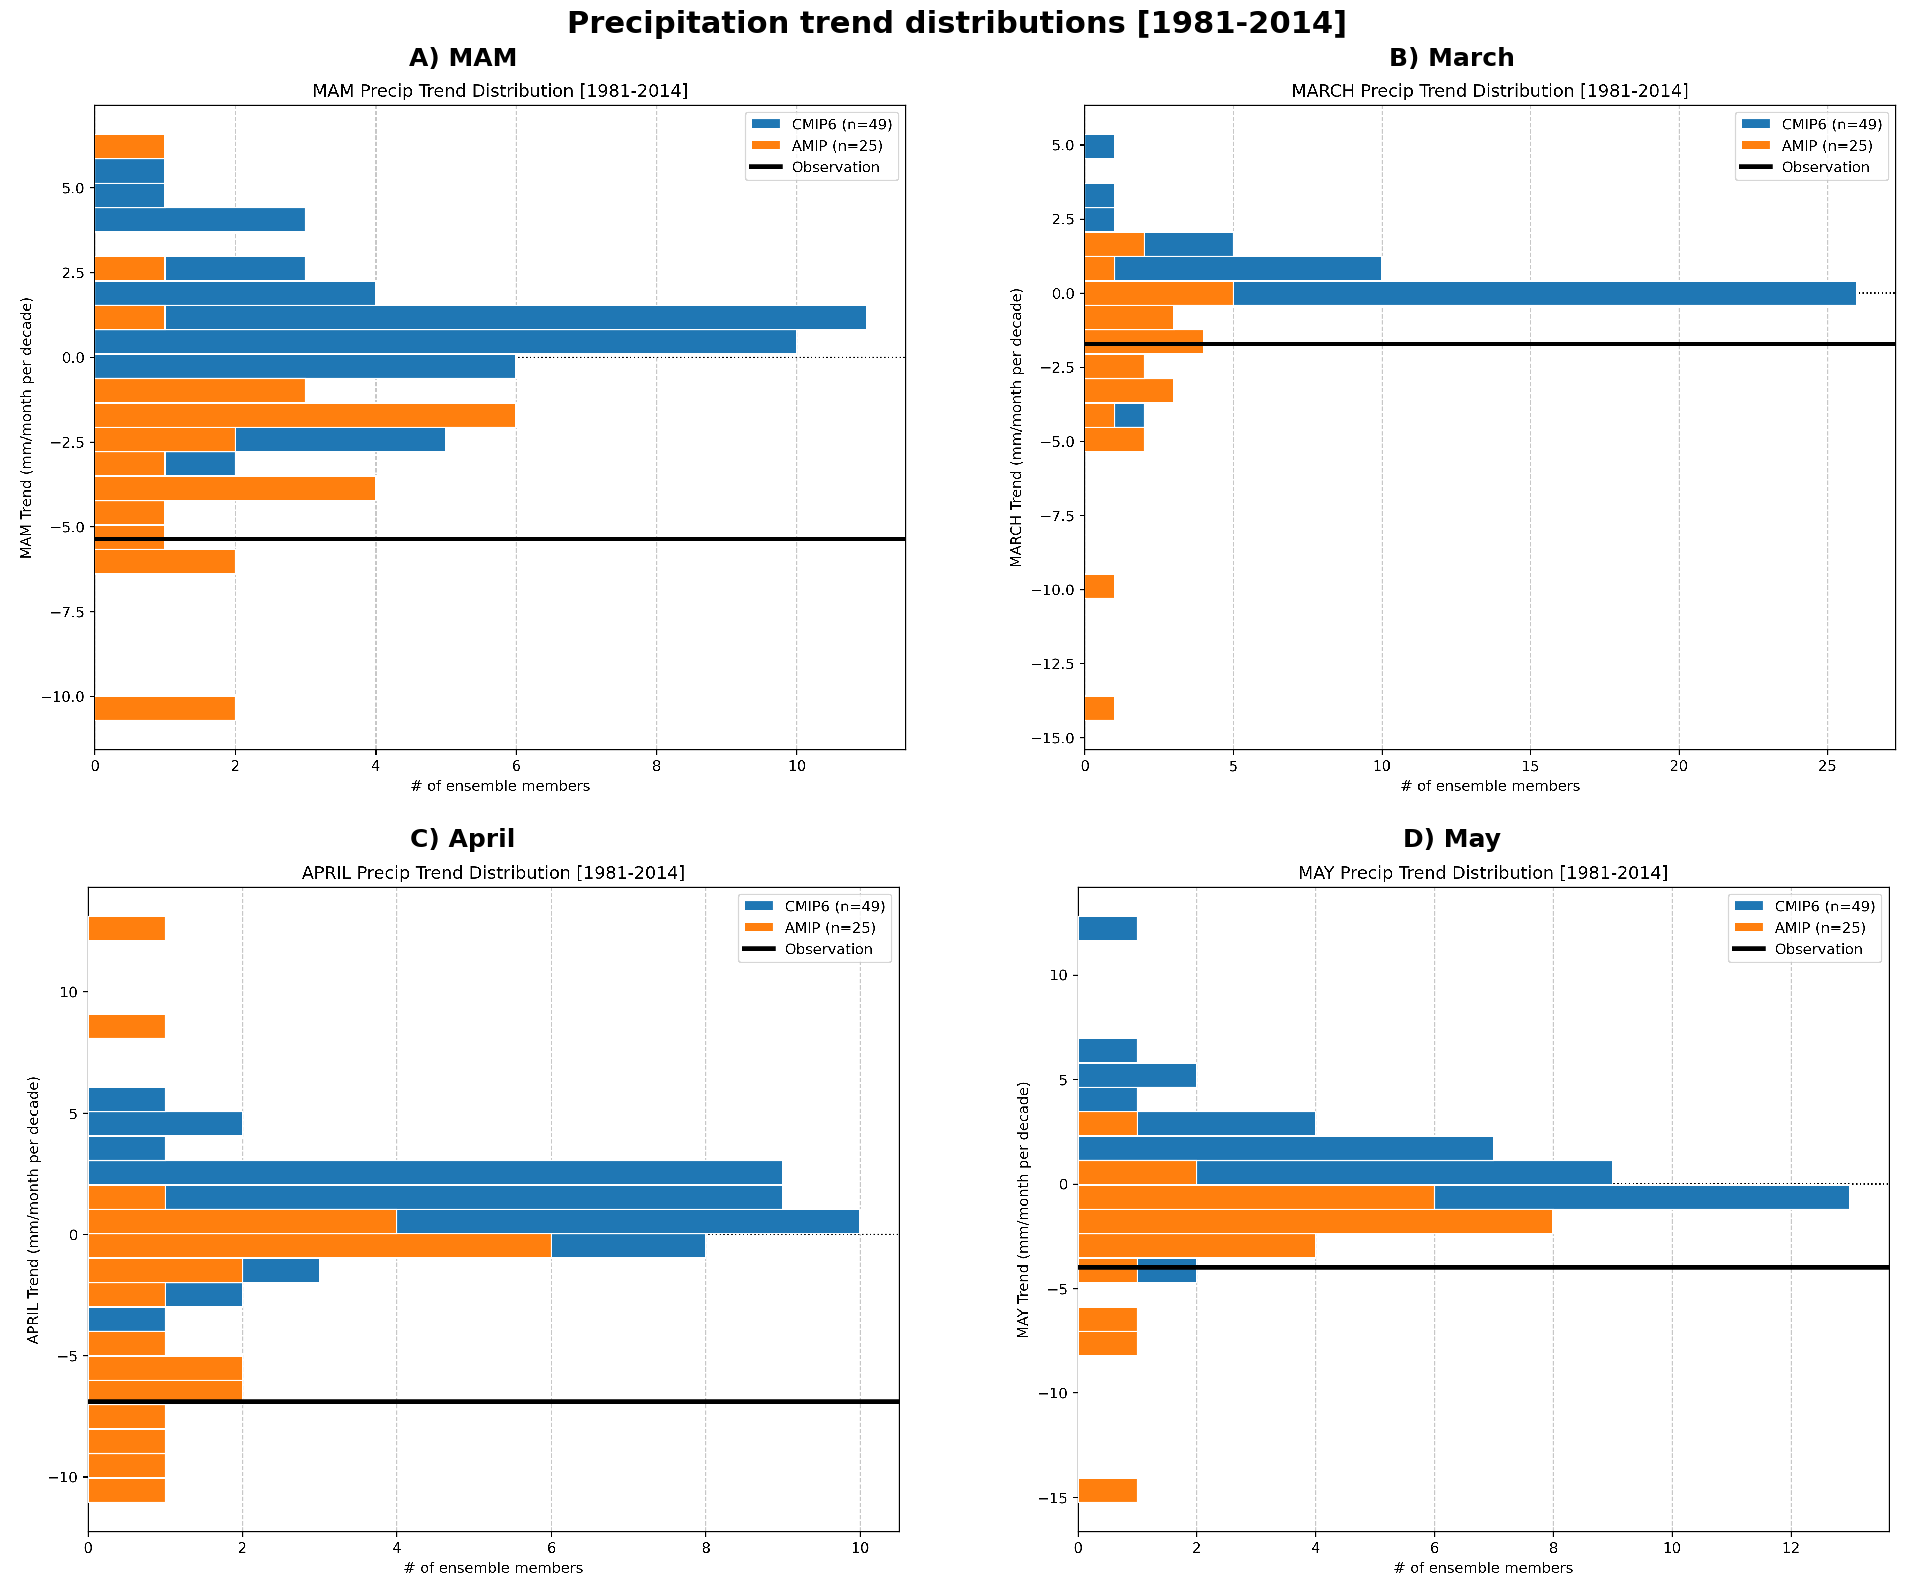

Saved: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/GROUPED_precip_trend_histograms_300dpi.png
Pixel dimensions: (6000, 4800)
DPI metadata: (299.9994, 299.9994)


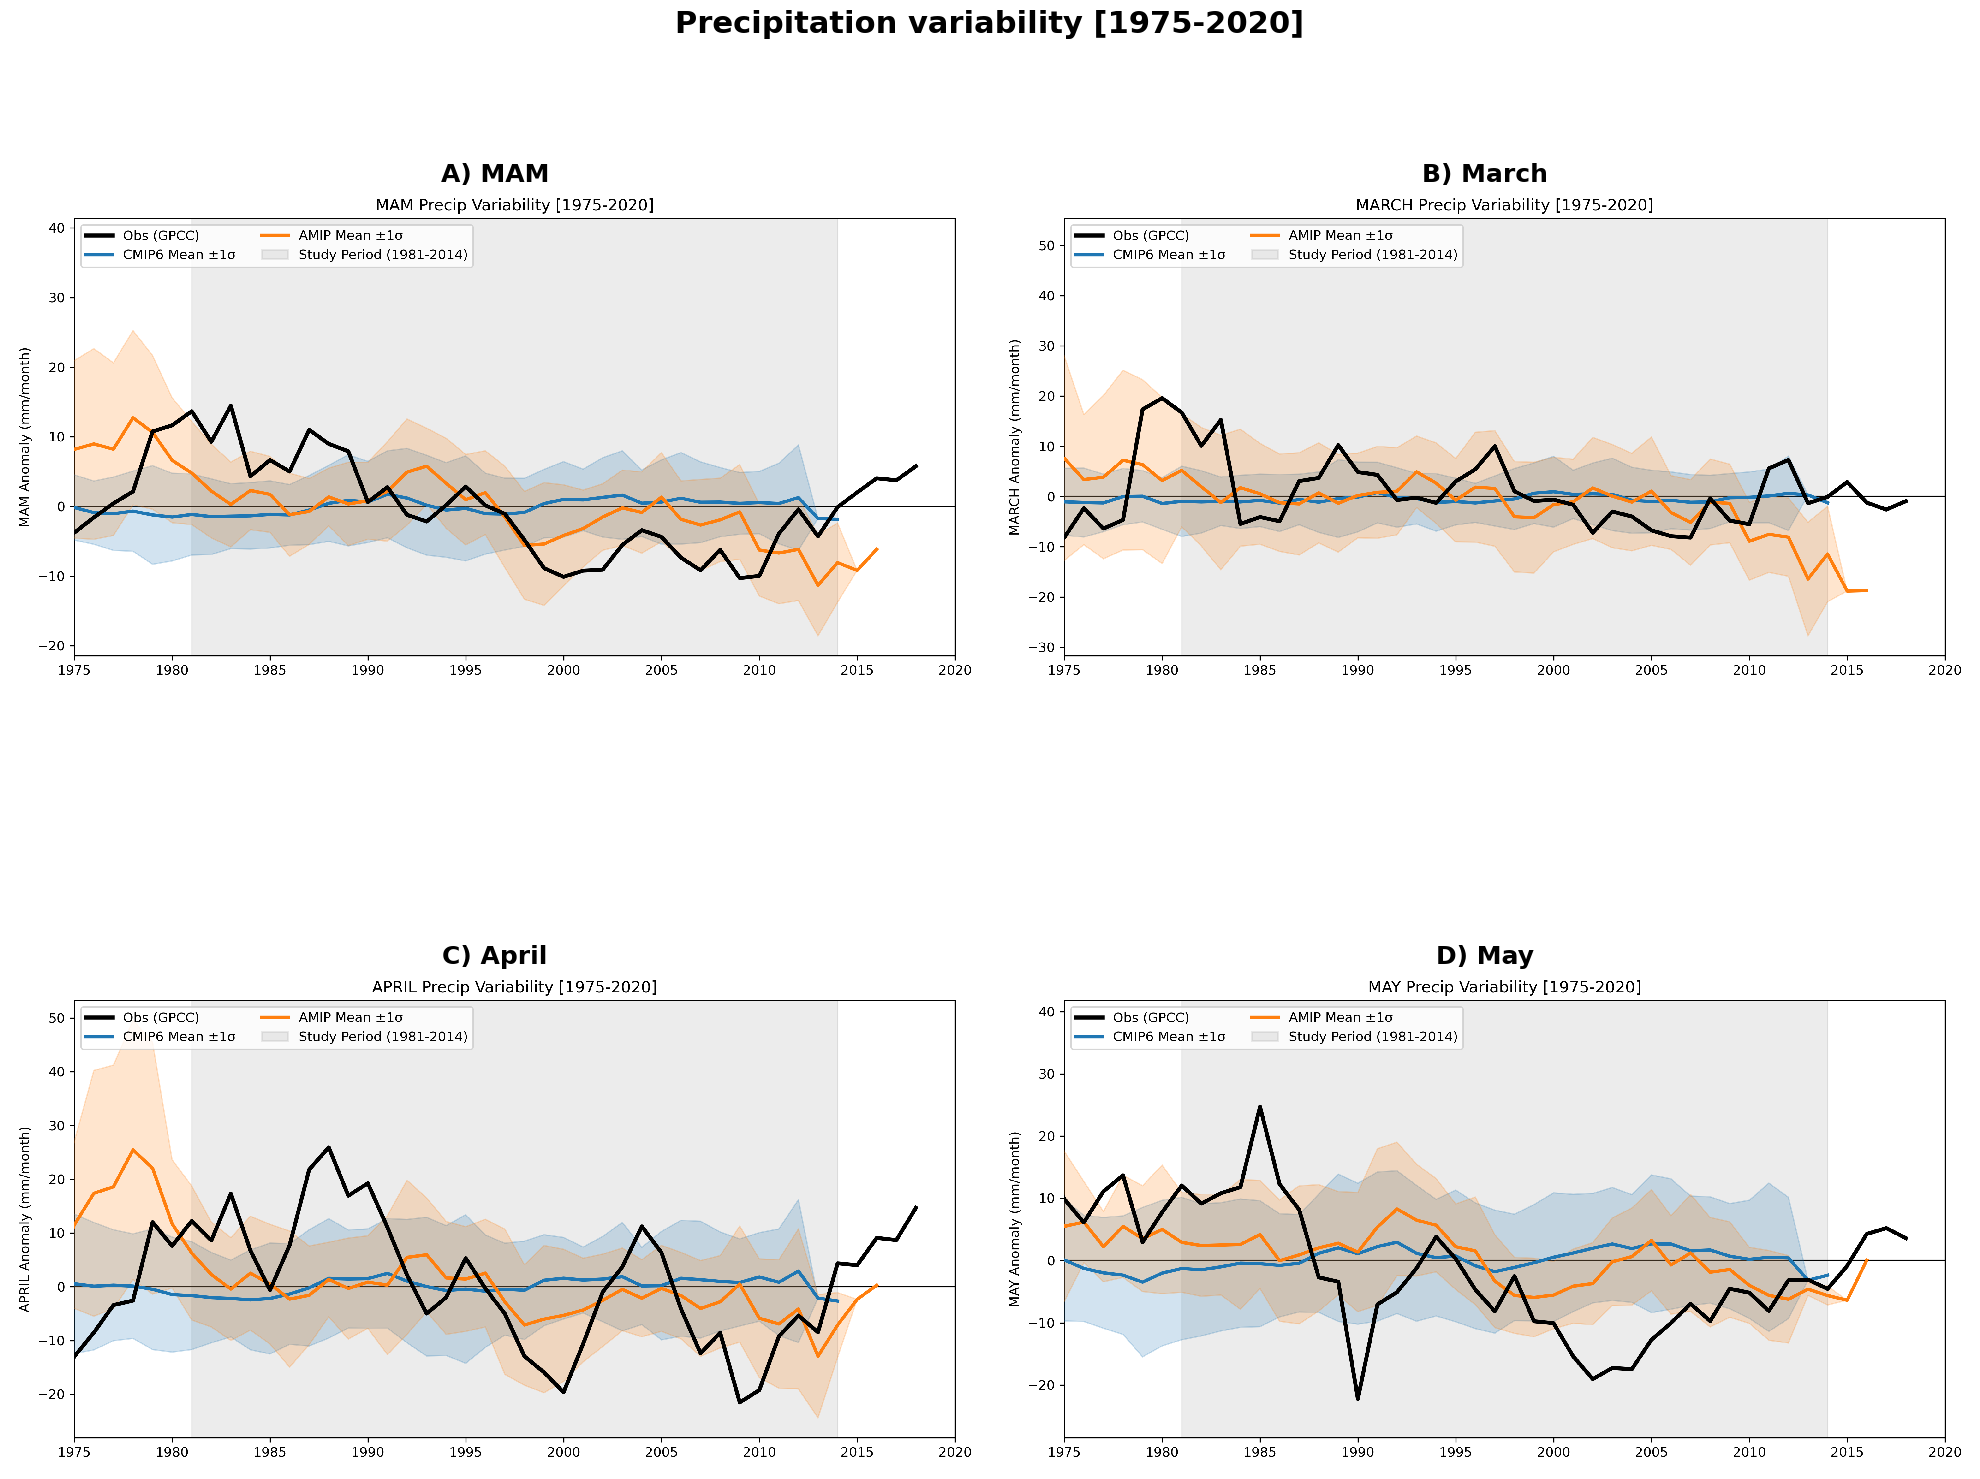

Saved: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/GROUPED_precip_timeseries_300dpi.png
Pixel dimensions: (6000, 4800)
DPI metadata: (299.9994, 299.9994)


PosixPath('/nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/GROUPED_precip_timeseries_300dpi.png')

In [25]:

group_saved_period_figures(
    "figure_precip_trend_histogram_{period}.png",
    "GROUPED_precip_trend_histograms_300dpi.png",
    f"Precipitation trend distributions [{CORE_START}-{CORE_END}]",
)

group_saved_period_figures(
    "figure_precip_timeseries_spaghetti_{period}.png",
    "GROUPED_precip_timeseries_300dpi.png",
    f"Precipitation variability [{TS_START_YEAR}-{TS_END_YEAR}]",
)

#group_saved_period_figures(
 #   "figure_extreme_trend_maps_{period}.png",
 #   "GROUPED_extreme_trend_maps_300dpi.png",
 #   f"Driest, middle and wettest tercile maps [{CORE_START}-{CORE_END}]",
 #   figsize=(28, 22),
#)


In [26]:

def extract_model_trend_rankings(data_cache):
    """Extract individual model trends, observation and ensemble means."""
    obs_val = np.nan

    obs_map = data_cache["obs"].get("trend_map")
    if obs_map is not None:
        obs_val = float(
            alib.get_region_mean(obs_map, "study")
        )

    rows = []
    ensemble_means = {}

    for group_name, models, color in [
        ("AMIP", data_cache["amip"], "tab:orange"),
        ("CMIP6", data_cache["cmip"], "tab:blue"),
    ]:
        group_values = []

        for model in models:
            trend_map = model.get("trend_map")
            if trend_map is None:
                continue

            value = float(
                alib.get_region_mean(trend_map, "study")
            )

            if not np.isfinite(value):
                continue

            model_name = str(model["name"])
            if group_name == "AMIP":
                model_name = f"{model_name} (AMIP)"

            rows.append(
                {
                    "name": model_name,
                    "value": value,
                    "group": group_name,
                    "color": color,
                }
            )
            group_values.append(value)

        if group_values:
            ensemble_means[group_name] = float(
                np.mean(group_values)
            )

    rows.sort(key=lambda item: item["value"])
    return rows, obs_val, ensemble_means


Loading ranking data for MAM...
Loading ranking data for March...


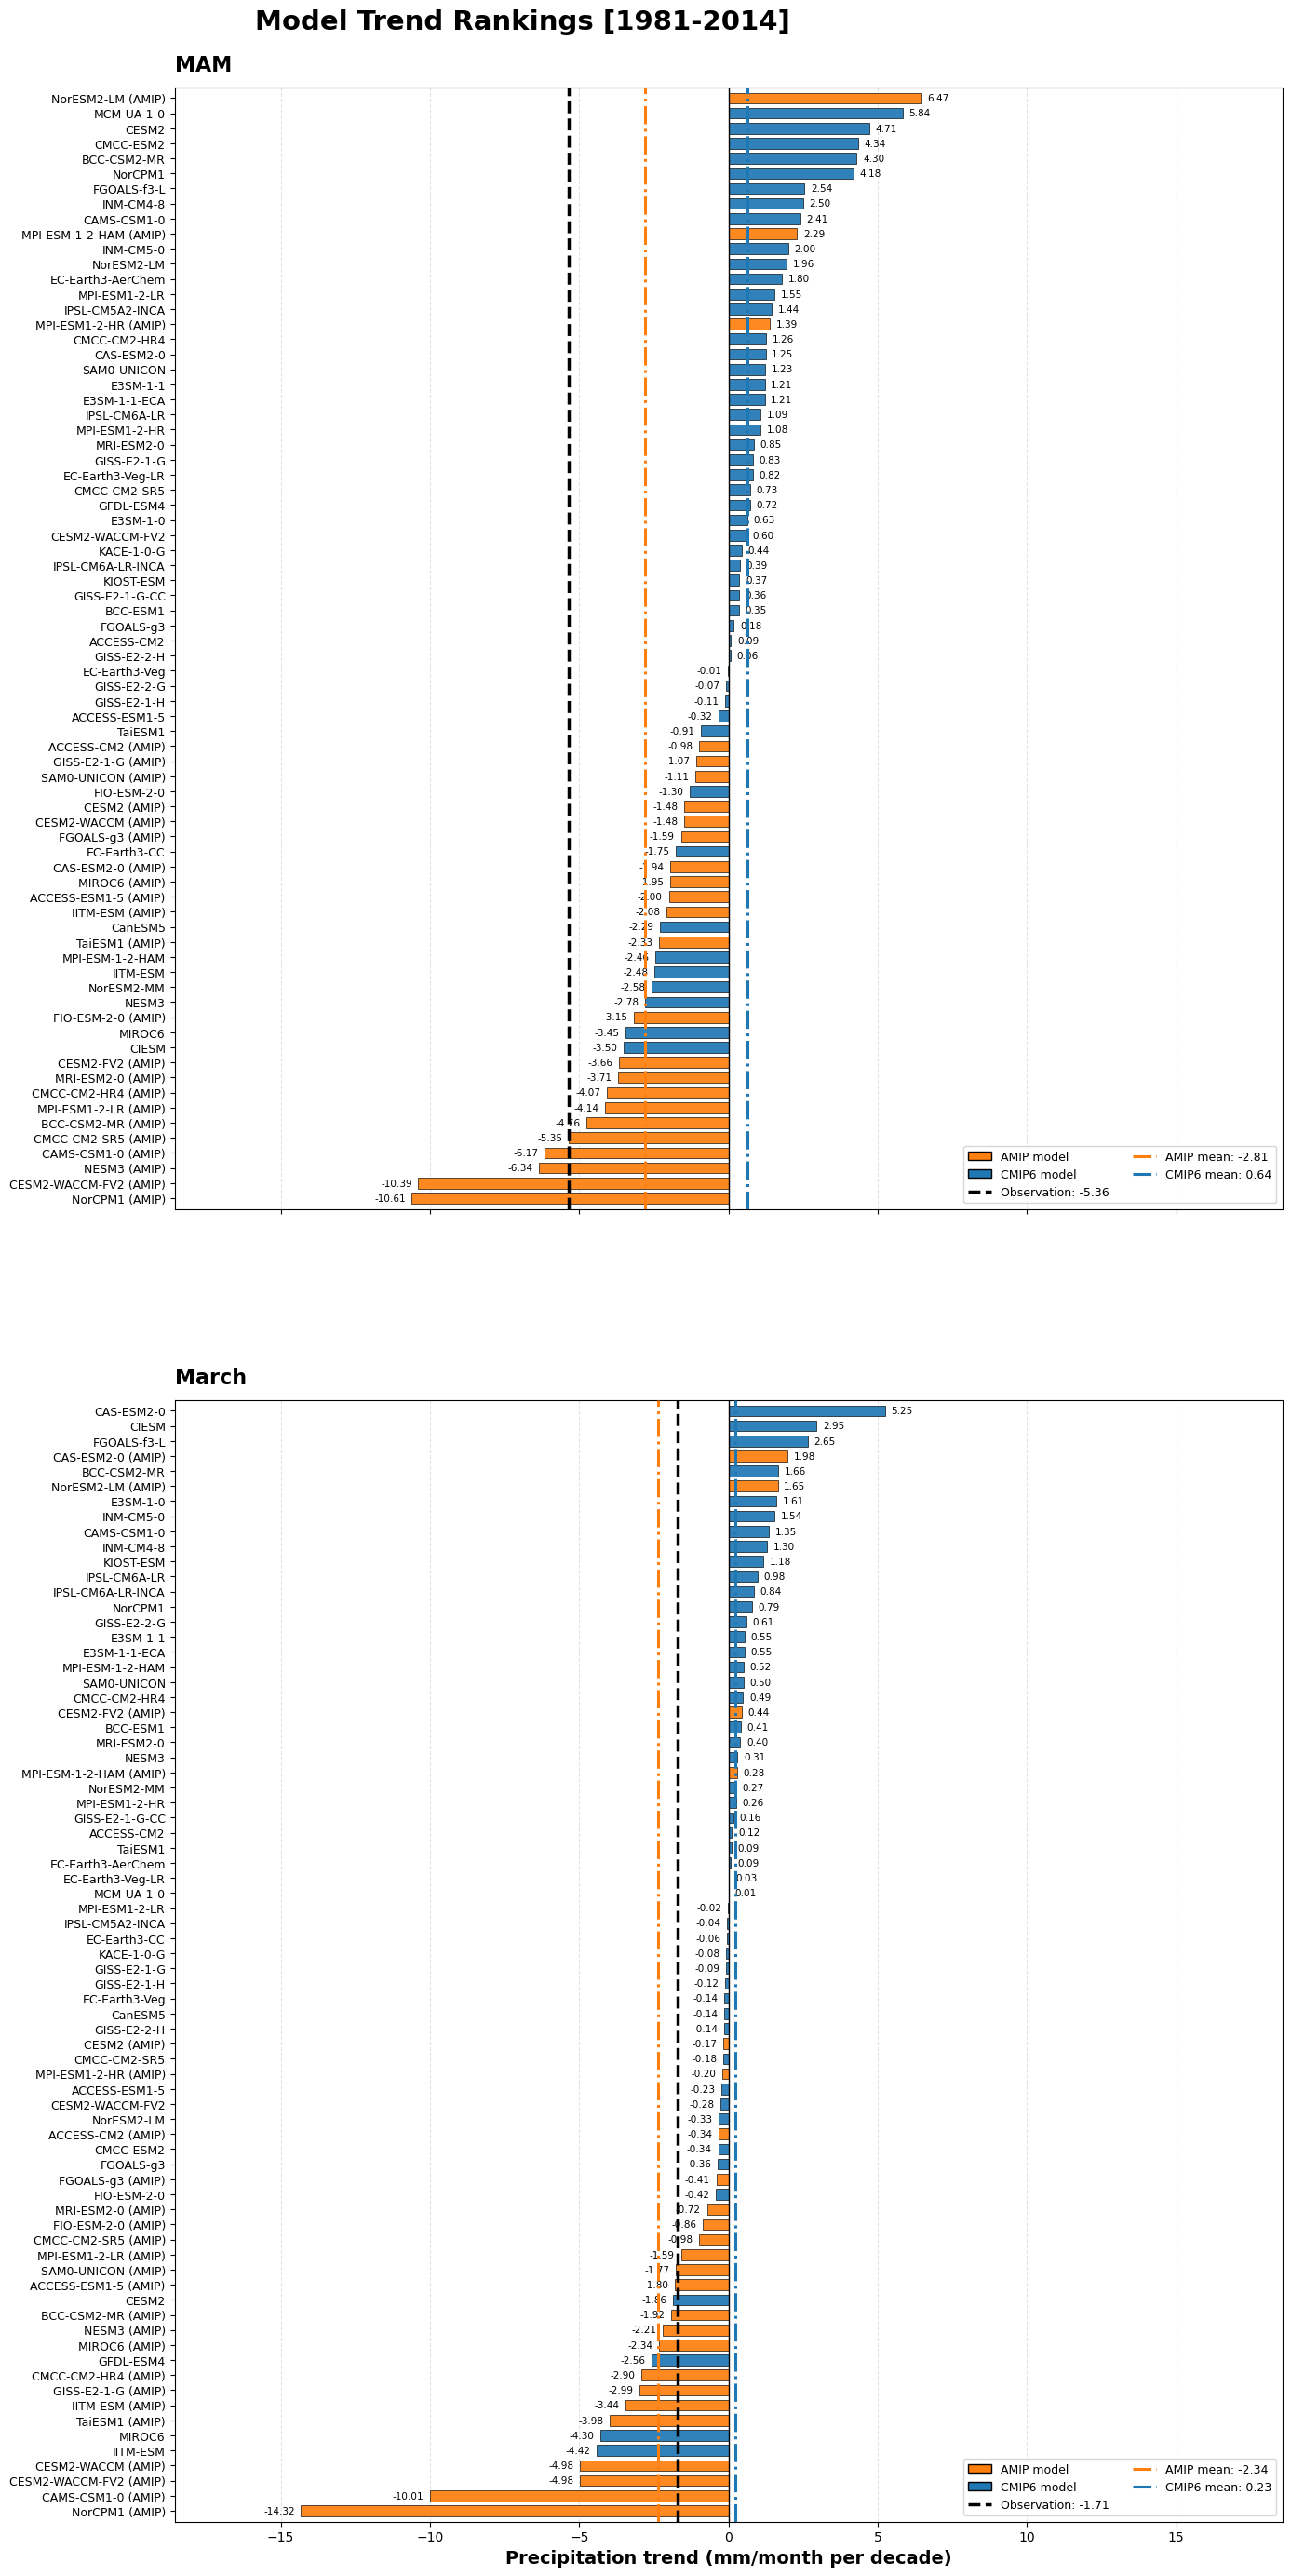

PNG saved: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/THESIS_model_rankings_MAM_March_300dpi.png
Pixel dimensions: (4163, 8301)
DPI metadata: (299.9994, 299.9994)
PDF saved: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/THESIS_model_rankings_MAM_March_300dpi.pdf
Loading ranking data for April...
Loading ranking data for May...


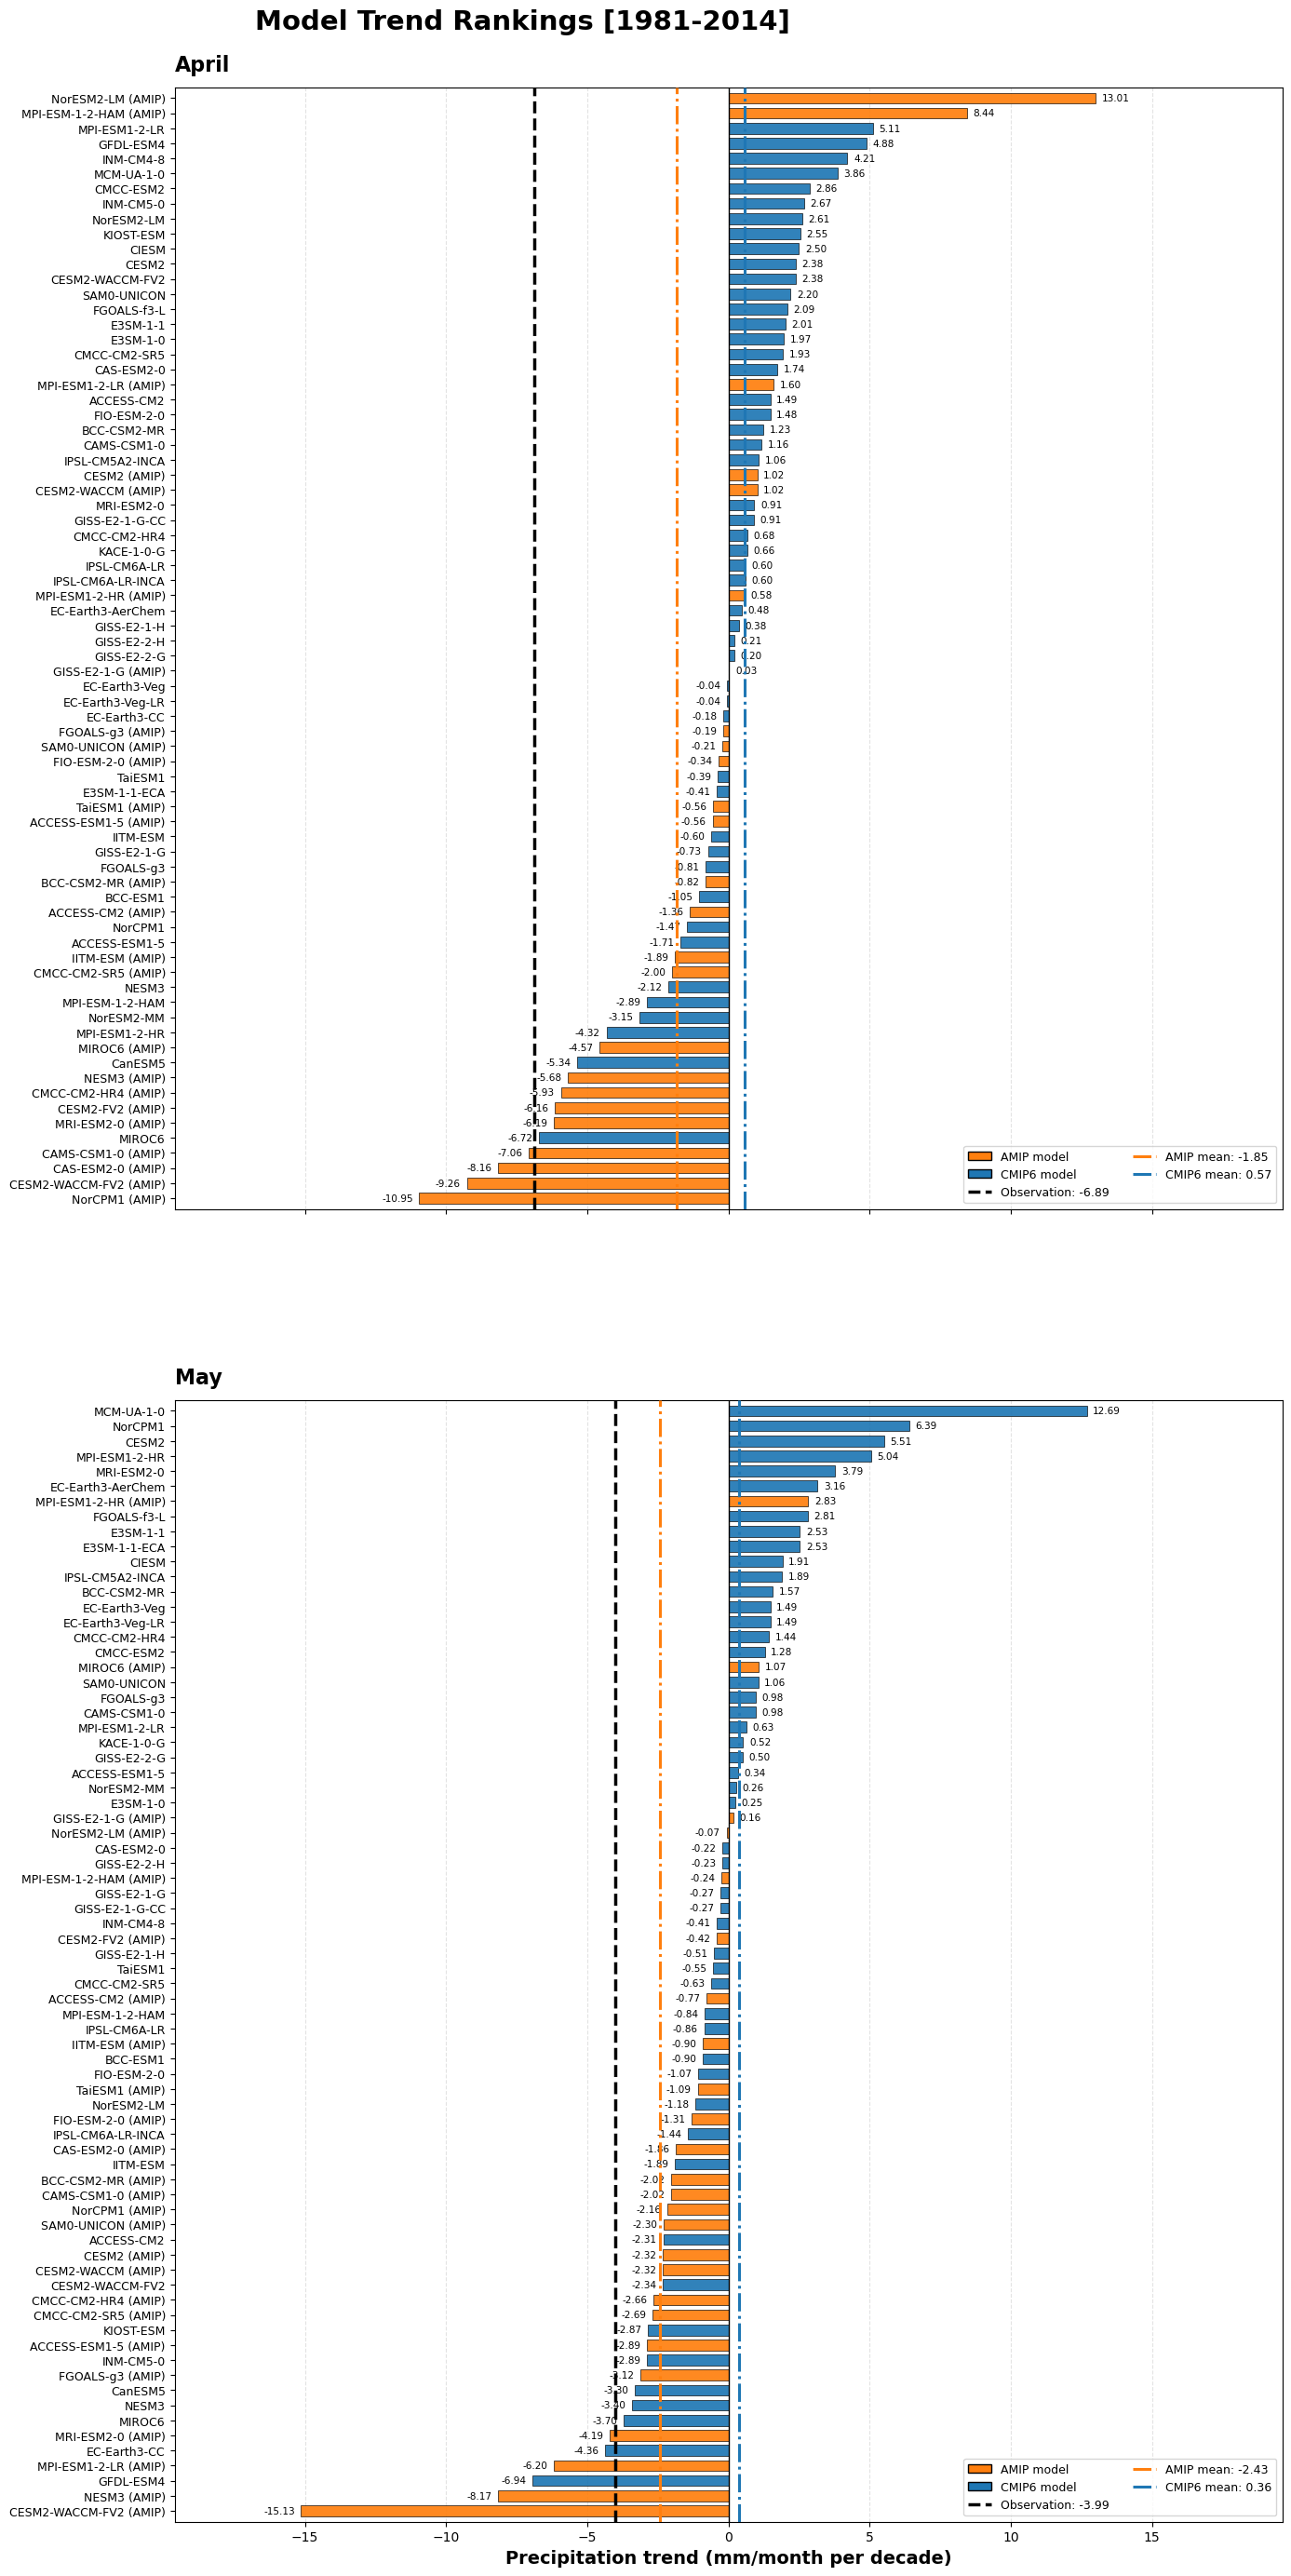

PNG saved: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/THESIS_model_rankings_April_May_300dpi.png
Pixel dimensions: (4163, 8301)
DPI metadata: (299.9994, 299.9994)
PDF saved: /nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/THESIS_model_rankings_April_May_300dpi.pdf


(PosixPath('/nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/THESIS_model_rankings_April_May_300dpi.png'),
 PosixPath('/nas/home/leo/Documents/scripts/regression_script/unified_analysis_output/figures/THESIS_model_rankings_April_May_300dpi.pdf'))

In [32]:
def create_clear_grouped_model_ranking(
    periods=GROUP_PERIODS,
    output_name="GROUPED_model_rankings_clear_300dpi.png",
    dpi=300,
):
    """
    Create clear model-ranking panels directly from the data.

    The layout is compact enough for a thesis while retaining space
    above each subplot for its period title.
    """
    prepared = []
    maximum_models = 0
    all_values = []

    # ---------------------------------------------------------
    # 1. Load and prepare the ranking data
    # ---------------------------------------------------------
    for period_key, period_label in periods:
        print(f"Loading ranking data for {period_label}...")

        # Reuse already-loaded data when available
        if "group_data" in globals() and period_key in group_data:
            data = group_data[period_key]
        else:
            data = alib.load_ranking_data(period_key)

        rows, obs_val, ensemble_means = (
            extract_model_trend_rankings(data)
        )

        prepared.append(
            {
                "label": period_label,
                "rows": rows,
                "obs": obs_val,
                "means": ensemble_means,
            }
        )

        maximum_models = max(
            maximum_models,
            len(rows),
        )

        all_values.extend(
            row["value"]
            for row in rows
        )

        if np.isfinite(obs_val):
            all_values.append(obs_val)

        all_values.extend(
            value
            for value in ensemble_means.values()
            if np.isfinite(value)
        )

    if not all_values:
        raise ValueError(
            "No valid model trend values were found."
        )

    # ---------------------------------------------------------
    # 2. Shared horizontal-axis range
    # ---------------------------------------------------------
    x_limit = max(
        abs(value)
        for value in all_values
    )

    x_limit = max(
        x_limit * 1.20,
        0.10,
    )

    # A smaller multiplier reduces figure length.
    panel_height = max(
        5.2,
        maximum_models * 0.19,
    )

    total_height = (
        panel_height * len(prepared)
    )

    # ---------------------------------------------------------
    # 3. Create figure
    # ---------------------------------------------------------
    fig, axes = plt.subplots(
        nrows=len(prepared),
        ncols=1,
        figsize=(17, total_height),
        sharex=True,
    )

    axes = np.atleast_1d(axes)

    model_handles = [
        Patch(
            facecolor="tab:orange",
            edgecolor="black",
            label="AMIP model",
        ),
        Patch(
            facecolor="tab:blue",
            edgecolor="black",
            label="CMIP6 model",
        ),
    ]

    # ---------------------------------------------------------
    # 4. Draw each period
    # ---------------------------------------------------------
    for ax, item in zip(axes, prepared):
        rows = item["rows"]

        names = [
            row["name"]
            for row in rows
        ]

        values = [
            row["value"]
            for row in rows
        ]

        colors = [
            row["color"]
            for row in rows
        ]

        positions = np.arange(
            len(rows)
        )

        bars = ax.barh(
            positions,
            values,
            color=colors,
            edgecolor="black",
            linewidth=0.5,
            height=0.72,
            alpha=0.92,
        )

        ax.set_yticks(positions)

        ax.set_yticklabels(
            names,
            fontsize=9,
        )

        # Reduce white space above and below the first/last bars.
        ax.margins(y=0.005)

        # -----------------------------------------------------
        # Add values at the ends of the bars
        # -----------------------------------------------------
        label_offset = x_limit * 0.012

        for bar, value in zip(
            bars,
            values,
        ):
            if value >= 0:
                label_x = value + label_offset
                alignment = "left"
            else:
                label_x = value - label_offset
                alignment = "right"

            ax.text(
                label_x,
                bar.get_y()
                + bar.get_height() / 2,
                f"{value:.2f}",
                va="center",
                ha=alignment,
                fontsize=7.5,
            )

        # Zero reference line
        ax.axvline(
            0,
            color="black",
            linewidth=1,
            zorder=1,
        )

        legend_handles = list(
            model_handles
        )

        # -----------------------------------------------------
        # Observation line
        # -----------------------------------------------------
        obs_val = item["obs"]

        if np.isfinite(obs_val):
            ax.axvline(
                obs_val,
                color="black",
                linestyle="--",
                linewidth=2.5,
                zorder=5,
            )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="black",
                    linestyle="--",
                    linewidth=2.5,
                    label=(
                        f"Observation: "
                        f"{obs_val:.2f}"
                    ),
                )
            )

        # -----------------------------------------------------
        # Ensemble-mean lines
        # -----------------------------------------------------
        means = item["means"]

        if "AMIP" in means:
            amip_mean = means["AMIP"]

            ax.axvline(
                amip_mean,
                color="tab:orange",
                linestyle="-.",
                linewidth=2.2,
                zorder=5,
            )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="tab:orange",
                    linestyle="-.",
                    linewidth=2.2,
                    label=(
                        f"AMIP mean: "
                        f"{amip_mean:.2f}"
                    ),
                )
            )

        if "CMIP6" in means:
            cmip_mean = means["CMIP6"]

            ax.axvline(
                cmip_mean,
                color="tab:blue",
                linestyle="-.",
                linewidth=2.2,
                zorder=5,
            )

            legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    color="tab:blue",
                    linestyle="-.",
                    linewidth=2.2,
                    label=(
                        f"CMIP6 mean: "
                        f"{cmip_mean:.2f}"
                    ),
                )
            )

        # -----------------------------------------------------
        # Axis formatting
        # -----------------------------------------------------
        ax.set_xlim(
            -x_limit * 1.08,
            x_limit * 1.08,
        )

        # Keep the period title above, not inside, the plotting area.
        ax.set_title(
            item["label"],
            loc="left",
            fontsize=16,
            fontweight="bold",
            y=1.01,
            pad=4,
        )

        ax.grid(
            axis="x",
            linestyle="--",
            alpha=0.35,
        )

        ax.set_axisbelow(True)

        ax.legend(
            handles=legend_handles,
            loc="lower right",
            fontsize=9,
            ncol=2,
            frameon=True,
        )

    # ---------------------------------------------------------
    # 5. Shared labels and main title
    # ---------------------------------------------------------
    axes[-1].set_xlabel(
        "Precipitation trend "
        "(mm/month per decade)",
        fontsize=14,
        fontweight="bold",
    )

    fig.suptitle(
        f"Model Trend Rankings "
        f"[{CORE_START}-{CORE_END}]",
        fontsize=21,
        fontweight="bold",
        y=0.995,
    )

    # hspace controls the gap between the subplot panels.
    # 0.17 keeps the titles outside without leaving a large gap.
    fig.subplots_adjust(
        left=0.28,
        right=0.98,
        top=0.965,
        bottom=0.035,
        hspace=0.17,
    )

    # ---------------------------------------------------------
    # 6. Save PNG and vector PDF
    # ---------------------------------------------------------
    output_path = (
        Path(config.FIGURE_DIR)
        / output_name
    )

    output_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    pdf_path = output_path.with_suffix(
        ".pdf"
    )

    fig.savefig(
        output_path,
        dpi=dpi,
        facecolor="white",
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        facecolor="white",
        bbox_inches="tight",
    )

    display(fig)
    plt.close(fig)

    with Image.open(output_path) as saved_image:
        print(f"PNG saved: {output_path}")
        print(
            f"Pixel dimensions: "
            f"{saved_image.size}"
        )
        print(
            f"DPI metadata: "
            f"{saved_image.info.get('dpi')}"
        )

    print(f"PDF saved: {pdf_path}")

    return output_path, pdf_path


# Create the two thesis-sized figures
create_clear_grouped_model_ranking(
    periods=GROUP_PERIODS[:2],
    output_name=(
        "THESIS_model_rankings_"
        "MAM_March_300dpi.png"
    ),
    dpi=300,
)

create_clear_grouped_model_ranking(
    periods=GROUP_PERIODS[2:],
    output_name=(
        "THESIS_model_rankings_"
        "April_May_300dpi.png"
    ),
    dpi=300,
)